In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [11]:
df = pd.read_csv("milky_production.csv")
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [12]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [13]:
df.tail()

,Date,Production
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797
167,1975-12,843


In [14]:
# Data-set Information
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [15]:
# Converting Data-column
df["Date"] = pd.to_datetime(df["Date"])

df.set_index("Date", inplace=True)

df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [16]:
# Missing values
df.isnull().sum()

Production    0
dtype: int64

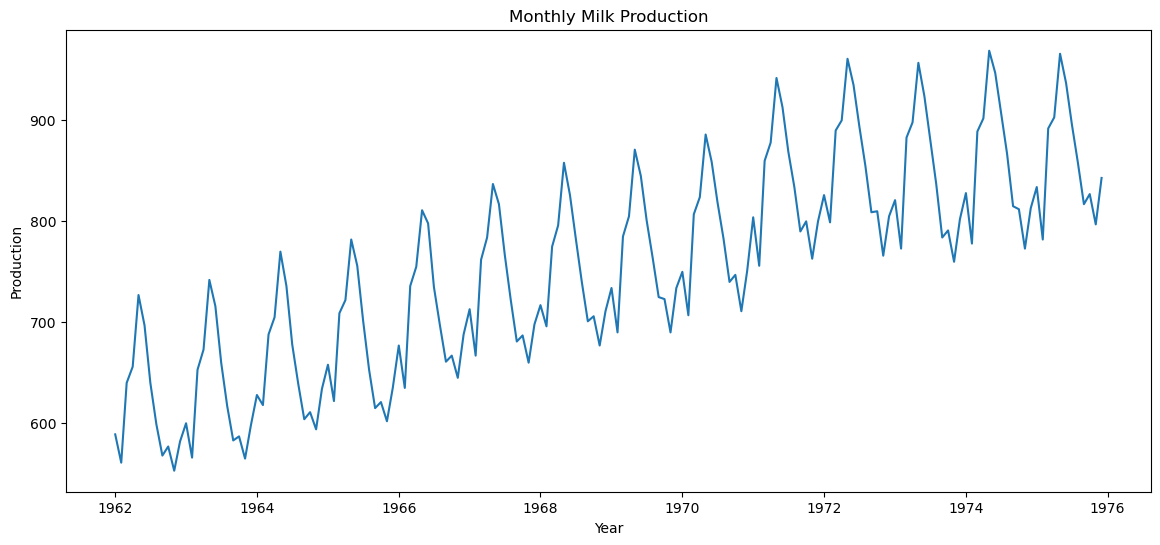

In [17]:
# Time series plot
plt.figure(figsize=(14,6))

plt.plot(df["Production"])

plt.title("Monthly Milk Production")

plt.xlabel("Year")

plt.ylabel("Production")

plt.show()

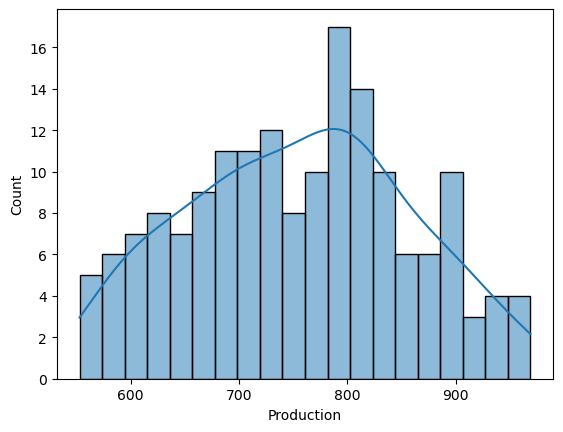

In [18]:
# Distribution
sns.histplot(df["Production"], bins=20, kde=True)

plt.show()

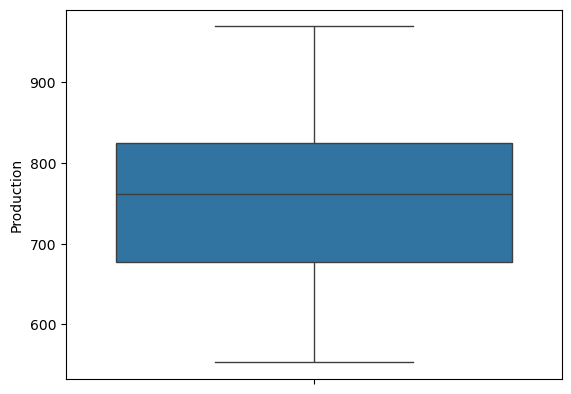

In [19]:
# Boxplot
sns.boxplot(y=df["Production"])

plt.show()

In [20]:
# Scalling data
scaler = MinMaxScaler()

scaled = scaler.fit_transform(df)

In [21]:
# Creating sequences
window = 12

X = []
y = []

for i in range(window, len(scaled)):
    X.append(scaled[i-window:i])
    y.append(scaled[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(156, 12, 1)
(156, 1)


In [22]:
# Train, Test, Split
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [23]:
# RNN Model
rnn = Sequential()

rnn.add(SimpleRNN(64, activation='tanh',
                  input_shape=(X_train.shape[1],1)))

rnn.add(Dense(1))

rnn.compile(loss='mse',
            optimizer='adam')

early = EarlyStopping(
    patience=10,
    restore_best_weights=True
)

history_rnn = rnn.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0332 - val_loss: 0.1182
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0111 - val_loss: 0.0033
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0070 - val_loss: 0.0444
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0055 - val_loss: 0.0086
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0029 - val_loss: 0.0140
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0030 - val_loss: 0.0143
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0023 - val_loss: 0.0074
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0017 - val_loss: 0.0159
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0015 - val_loss: 0.0071
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0017 - val_loss: 0.0123
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0016 - val_loss: 0.0081
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0013 - val_lo

In [24]:
# LTSM Model
lstm = Sequential()

lstm.add(LSTM(
    64,
    input_shape=(X_train.shape[1],1)
))

lstm.add(Dense(1))

lstm.compile(
    optimizer='adam',
    loss='mse'
)

history_lstm = lstm.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.1396 - val_loss: 0.2060
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0447 - val_loss: 0.0370
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0315 - val_loss: 0.0324
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0288 - val_loss: 0.0337
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0241 - val_loss: 0.0475
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0255 - val_loss: 0.0472
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0244 - val_loss: 0.0359
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0236 - val_loss: 0.0271
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0238 - val_loss: 0.0279
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0229 - val_loss: 0.0307


In [25]:
# GRU model 
gru = Sequential()

gru.add(GRU(
    64,
    input_shape=(X_train.shape[1],1)
))

gru.add(Dense(1))

gru.compile(
    optimizer='adam',
    loss='mse'
)

history_gru = gru.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early],
    verbose=1
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.1665 - val_loss: 0.2692
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0531 - val_loss: 0.0590
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0304 - val_loss: 0.0244
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0319 - val_loss: 0.0389
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0249 - val_loss: 0.0673
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0253 - val_loss: 0.0591
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0239 - val_loss: 0.0441
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0224 - val_loss: 0.0399
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0224 - val_loss: 0.0354
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0215 - val_loss: 0.0412


In [26]:
# Prediction
rnn_pred = rnn.predict(X_test)

lstm_pred = lstm.predict(X_test)

gru_pred = gru.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step


In [27]:
# Converting bact to original Scale
rnn_pred = scaler.inverse_transform(rnn_pred)

lstm_pred = scaler.inverse_transform(lstm_pred)

gru_pred = scaler.inverse_transform(gru_pred)

actual = scaler.inverse_transform(y_test)

In [28]:
# Evaluation function
def evaluate(actual,pred):

    rmse = np.sqrt(mean_squared_error(actual,pred))

    mae = mean_absolute_error(actual,pred)

    mape = np.mean(np.abs((actual-pred)/actual))*100

    return rmse,mae,mape

In [29]:
# Evalueted model
rnn_score = evaluate(actual,rnn_pred)

lstm_score = evaluate(actual,lstm_pred)

gru_score = evaluate(actual,gru_pred)

print("RNN :",rnn_score)

print("LSTM :",lstm_score)

print("GRU :",gru_score)

RNN : (np.float64(28.11515926136025), 23.162233352661122, np.float64(2.6767936669004193))
LSTM : (np.float64(191.41868065736082), 180.34590530395508, np.float64(20.64983163134093))
GRU : (np.float64(221.33141115029935), 212.07160758972168, np.float64(24.382598889168456))


In [30]:
# Comparison Table
results = pd.DataFrame({

    "Model":["RNN","LSTM","GRU"],

    "RMSE":[
        rnn_score[0],
        lstm_score[0],
        gru_score[0]
    ],

    "MAE":[
        rnn_score[1],
        lstm_score[1],
        gru_score[1]
    ],

    "MAPE":[
        rnn_score[2],
        lstm_score[2],
        gru_score[2]
    ]
})

results

,Model,RMSE,MAE,MAPE
0,RNN,28.115159,23.162233,2.676794
1,LSTM,191.418681,180.345905,20.649832
2,GRU,221.331411,212.071608,24.382599


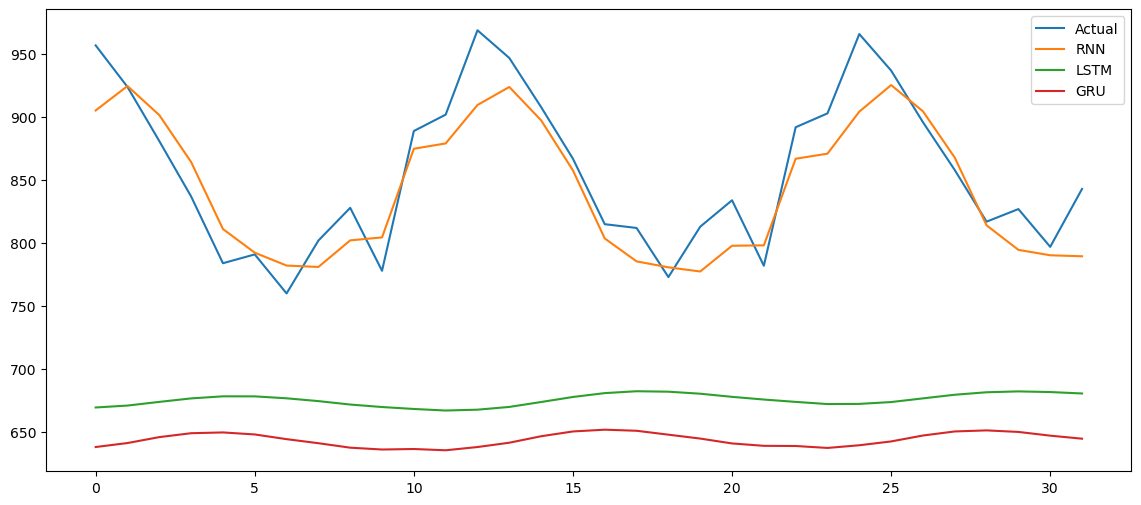

In [31]:
# Prediction plot
plt.figure(figsize=(14,6))

plt.plot(actual,label="Actual")

plt.plot(rnn_pred,label="RNN")

plt.plot(lstm_pred,label="LSTM")

plt.plot(gru_pred,label="GRU")

plt.legend()

plt.show()

In [33]:
# Forecasting for next 12 months
future = scaled[-12:].reshape(1, 12, 1)

forecast = []

model = gru   # or lstm

for i in range(12):

    pred = model.predict(future, verbose=0)

    forecast.append(pred[0,0])

    # create a (1,1,1) array
    pred = pred.reshape(1,1,1)

    # slide the window
    future = np.concatenate(
        (future[:,1:,:], pred),
        axis=1
    )

forecast = scaler.inverse_transform(np.array(forecast).reshape(-1,1))

forecast

array([[641.7865 ],
       [641.4808 ],
       [634.7807 ],
       [627.68164],
       [621.79297],
       [617.22644],
       [613.8348 ],
       [611.354  ],
       [609.5514 ],
       [608.25116],
       [607.29047],
       [606.60425]], dtype=float32)

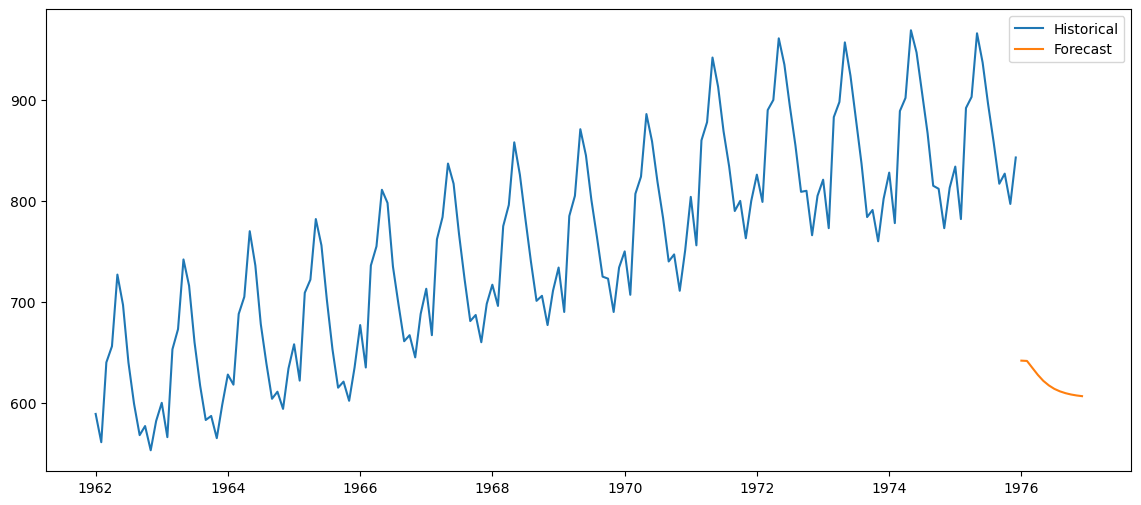

In [34]:
# Forecast plot
future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)

forecast_df = pd.DataFrame({
    "Date":future_dates,
    "Forecast":forecast.flatten()
})

plt.figure(figsize=(14,6))

plt.plot(df.index,
         df["Production"],
         label="Historical")

plt.plot(forecast_df["Date"],
         forecast_df["Forecast"],
         label="Forecast")

plt.legend()

plt.show()

# Business Insights

Milk production follows a seasonal pattern.
    
Forecasts help estimate production for the next 12 months.
    
The dairy industry can use predictions for inventory management.
    
Accurate forecasts reduce storage costs and wastage.
    
Production planning helps optimize workforce and logistics.
    
Forecasts support strategic business decisions and demand planning.